# Schur signal propagation: normalized with-self vs no-self

Each state matrix is normalized independently to spectral radius 0.95, then every Schur seed mode is propagated through the complete coupled cascade.

## Notebook role in the analysis sequence

**Role:** Companion to `03_schur_signal.ipynb`.

**Inputs:**
- `matrices/mij_matrix.csv`

**Outputs:**
- `outputs/schur_modes/self_comparison/model_summary.csv`
- `outputs/schur_modes/self_comparison/timestep_summary.csv`
- `outputs/schur_modes/self_comparison/propagation_by_variant.csv`

**What this notebook adds:**
- Compares Schur signal propagation with and without self-connections.
- Uses matched independent spectral-radius normalization to `0.95`.
- Tests whether propagation strength and non-normality are driven by diagonal or off-diagonal structure.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display
from schur_signal_propagation_script import compare_self_propagation

MATRIX_PATH = Path('matrices/mij_matrix.csv')
OUTPUT_DIR = Path('outputs/schur_modes/self_comparison')

## Run all-mode propagation

In [2]:
comparison = compare_self_propagation(
    MATRIX_PATH,
    normalization='spectral_radius',
    target_spectral_radius=0.95,
    timesteps=10,
    top_n=5,
)
display(comparison['model_summary'])

,variant,normalization,original_spectral_radius,achieved_spectral_radius,scale_factor,matrix_fro_norm,non_normality
0,with_self,spectral_radius,26213.130121,0.95,0.000036,77.182134,5869.903453
1,no_self,spectral_radius,14837.865933,0.95,0.000064,136.346623,18319.829226


## Aggregate propagation by timestep

,variant,timestep,mean,median,max,sum
0,no_self,0,0.309045,0.282158,0.921287,131.344319
1,no_self,1,0.263846,0.112055,2.944963,112.134387
2,no_self,2,0.170935,0.071961,1.889812,72.647305
3,no_self,3,0.151818,0.071372,1.646914,64.522853
4,no_self,4,0.131599,0.054872,2.898600,55.929742
5,no_self,5,0.127724,0.068587,2.375549,54.282896
6,no_self,6,0.116393,0.048747,2.676507,49.466889
7,no_self,7,0.111310,0.053681,2.093570,47.306696
8,no_self,8,0.104207,0.045644,2.367179,44.287955
9,no_self,9,0.098230,0.048023,1.942849,41.747853


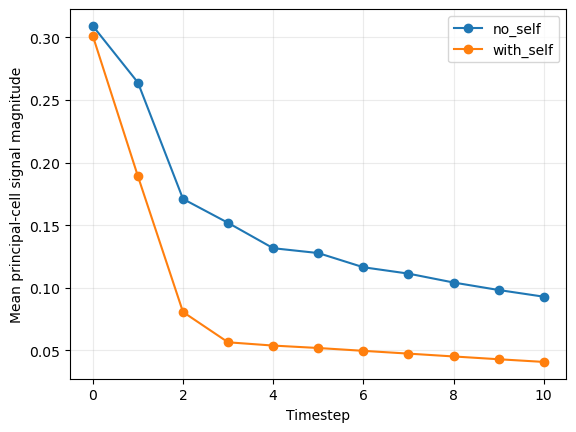

In [3]:
timestep_summary = comparison['timestep_summary']
display(timestep_summary)
for variant, table in timestep_summary.groupby('variant'):
    plt.plot(table['timestep'], table['mean'], marker='o', label=variant)
plt.xlabel('Timestep')
plt.ylabel('Mean principal-cell signal magnitude')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## Largest propagated signals

In [4]:
largest = (
    comparison['propagation']
    .sort_values('signal_magnitude', ascending=False)
    .groupby('variant')
    .head(20)
)
display(largest)

,variant,seed_mode,eigenvalue,timestep,loading_rank,cell_type,initial_mode_loading,signal_real,signal_imag,signal_magnitude
3529,with_self,64,0.000147-0.000078j,1,5,CA1 SO SO (I),0.187520+0.072194j,-2.790937,1.806433,3.324534
3362,with_self,61,0.000147+0.000078j,1,3,CA1 Oriens Alveus (I),0.239269-0.209494j,-0.956389,2.866332,3.021678
5230,no_self,10,0.190133-0.000000j,1,1,DG Axo Axonic (I),-0.122496-0.356479j,0.957045,2.785116,2.944963
6734,no_self,37,-0.014865+0.000000j,4,5,CA1 OR LM (I),-0.255824+0.009032j,-2.896795,0.102272,2.898600
3031,with_self,55,0.000412-0.000070j,1,2,CA1 Bistratified (I),0.123324+0.353562j,-1.811547,-2.242572,2.882852
6169,no_self,27,-0.045370-0.002540j,1,5,DG HICAP (I),0.145720-0.162159j,-1.987823,1.943590,2.780105
6744,no_self,37,-0.014865+0.000000j,6,5,CA1 OR LM (I),-0.255824+0.009032j,-2.674841,0.094435,2.676507
227,with_self,4,-0.310286-0.000000j,1,3,DG AIPRIM (I),0.297838-0.088147j,-2.450842,0.725346,2.555925
6739,no_self,37,-0.014865+0.000000j,5,5,CA1 OR LM (I),-0.255824+0.009032j,-2.374070,0.083817,2.375549
6754,no_self,37,-0.014865+0.000000j,8,5,CA1 OR LM (I),-0.255824+0.009032j,-2.365705,0.083521,2.367179


## Save comparison tables

In [5]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
comparison['model_summary'].to_csv(OUTPUT_DIR / 'model_summary.csv', index=False)
comparison['timestep_summary'].to_csv(OUTPUT_DIR / 'timestep_summary.csv', index=False)
comparison['propagation'].to_csv(OUTPUT_DIR / 'propagation_by_variant.csv', index=False)
print(f'Saved comparison tables to {OUTPUT_DIR.resolve()}')

Saved comparison tables to C:\Users\ranic\Documents\GitHub\schur_decomp\outputs\schur_modes\self_comparison
